In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

IMEI: 869487064548620

In [2]:
#12-07-2026 - 13-07-2026
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\cea\EHK428.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  98 non-null     str  
 1   Message  98 non-null     str  
 2   Status   98 non-null     str  
dtypes: str(3)
memory usage: 2.4 KB


In [3]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252513    98
Name: count, dtype: int64

In [4]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  98 non-null     str  
 1   Message  98 non-null     str  
 2   Status   98 non-null     str  
 3   Headers  98 non-null     str  
dtypes: str(4)
memory usage: 3.2 KB


Odometer

In [5]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             98 non-null     str  
 1   Message             98 non-null     str  
 2   Status              98 non-null     str  
 3   Headers             98 non-null     str  
 4   Odometer in meters  98 non-null     int64
 5   Date                98 non-null     str  
 6   Raw data            98 non-null     str  
dtypes: int64(1), str(6)
memory usage: 5.5 KB
None


260712021811 -> 0 -> 14104300.0 -> 0x252513005962F60869487064548620003C38402D000000485000000007000020000000FFFFFFFFFFFFFFFFFFFF00D500D736EC852607120218113373C044E63397C28CFAC7400000000003861293FFFFFF00001F0000FFFFFF
260712040249 -> 1 -> 14104325.0 -> 0x252513005962F70869487064548620003C38402D0000003E4B00000007000020000000FFFFFFFFFFFFFFFFFFFF00D500D737058526071204024966D6C044EC3397C2C1F8C7400110009903861290FFFFFF00001D0001FFFFFF
260712040314 -> 2 -> 14104344.0 -> 0x252513005962F80869487064548620003C38402D0000004B4B00000007000020000000FFFFFFFFFFFFFFFFFFFF00D500D737188526071204031400A0C044E73397C2D7F7C7400160014E03861290FFFFFF00001D0001FFFFFF
260712040329 -> 3 -> 14104382.0 -> 0x252513005962F90869487064548620003C38402D0000004B4900000007000020000000FFFFFFFFFFFFFFFFFFFF00D500D7373E852607120403299A89BF44E73397C283F9C7400110009E03861290FFFFFF00001E0001FFFFFF
260712040343 -> 4 -> 14104429.0 -> 0x252513005962FA0869487064548620003C38402D000000444A00000007000020000000FFFFFFFFFFFFFFFFFFFF00D500D73

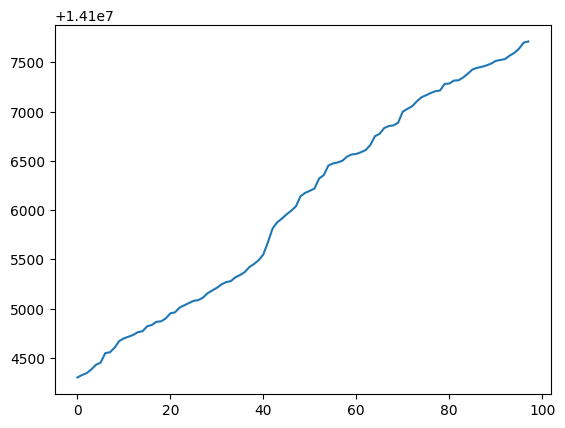

In [6]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

In [7]:
y_axis_sr=[]
x_axis_sr=[]
date_sr=[]
raw_data_sr=[]
speed_sr=[]
bottom_lim=14105675-300
upper_lim=14105675+300
unit.info()

for i in range(0,unit.shape[0]):
    #print(unit.iloc[i,4],'->',bottom_lim,'->',upper_lim)
    if unit.iloc[i,4]>bottom_lim and unit.iloc[i,4]<upper_lim:
        y_axis_sr.append(float(unit.iloc[i,4]))
        x_axis_sr.append(i)
        date_sr.append(unit.iloc[i,3])
        raw_data_sr.append(unit.iloc[i,2])
        speed_sr.append(int(unit.iloc[i,2][142:145]))  
        print(bottom_lim,'->',unit.iloc[i,4],'->',upper_lim,'->',unit.iloc[i,2][142:145])

report_highspeed_sr=pd.DataFrame()
report_highspeed_sr['Date']=date_sr
report_highspeed_sr['Raw data']=raw_data_sr
report_highspeed_sr['Speed']=speed_sr
report_highspeed_sr['odometer']=y_axis_sr

report_highspeed_sr.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\cea\869487064548620_1.csv')

<class 'pandas.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             98 non-null     str  
 1   Message             98 non-null     str  
 2   Status              98 non-null     str  
 3   Headers             98 non-null     str  
 4   Odometer in meters  98 non-null     int64
 5   Date                98 non-null     str  
 6   Raw data            98 non-null     str  
dtypes: int64(1), str(6)
memory usage: 5.5 KB
14105375 -> 14105421 -> 14105975 -> 058
14105375 -> 14105452 -> 14105975 -> 029
14105375 -> 14105491 -> 14105975 -> 044
14105375 -> 14105549 -> 14105975 -> 050
14105375 -> 14105675 -> 14105975 -> 123
14105375 -> 14105814 -> 14105975 -> 073
14105375 -> 14105876 -> 14105975 -> 044
14105375 -> 14105913 -> 14105975 -> 032
14105375 -> 14105956 -> 14105975 -> 063


Speed

In [8]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            #print(lbs_ind)
    except:
        pass 
    
unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Speed     98 non-null     int64
 1   Date      98 non-null     str  
 2   Raw data  98 non-null     str  
dtypes: int64(1), str(2)
memory usage: 2.4 KB
None


260712185640 -> 41 -> 123.0 -> 0x2525130059631F0869487064548620003C38402D0000003E4600000007000020000000FFFFFFFFFFFFFFFFFFFF00D500D73C4B83260712185640CD2CC344A63397C26FF6C7401230008803851279FFFFFF00001D0005FFFFFF


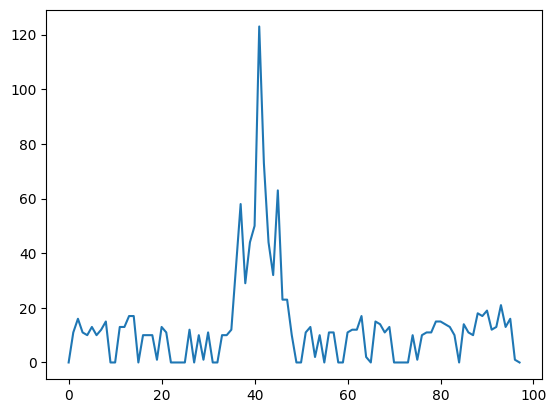

In [9]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]
date_report=[]
x_axis_report=[]
y_axis_report=[]
raw_data_report=[]
report_higspeed=pd.DataFrame()

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])
    #print(raw_data_[i])
    
for i in range(0,len(speed)):
    if (y_axis[i]>100):
        date_report.append(date[i])
        x_axis_report.append(x_axis[i])
        y_axis_report.append(y_axis[i])
        raw_data_report.append(raw_data_[i])
        print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

report_higspeed['Date']=date_report
report_higspeed['Index']=x_axis_report
report_higspeed['Speed']=y_axis_report  
report_higspeed['Raw data']=raw_data_report

#report_higspeed.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\cea\EHK428_highspeed.csv')
plt.plot(x_axis,y_axis)

Satellites

In [10]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)
unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<1:
        num_events=num_events+1
        print(unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,5],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         98 non-null     str  
 1   Message                         98 non-null     str  
 2   Status                          98 non-null     str  
 3   Headers                         98 non-null     str  
 4   Satellites                      98 non-null     int64
 5   Satellite_connection_indicator  98 non-null     int64
 6   Raw data                        98 non-null     str  
 7   date                            98 non-null     str  
dtypes: int64(2), str(6)
memory usage: 6.3 KB
Eventos históricos:  0


In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [11]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16)))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

#in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\in_outs.csv')

<class 'pandas.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  98 non-null     str  
 1   Message  98 non-null     str  
 2   Status   98 non-null     str  
 3   Headers  98 non-null     str  
dtypes: str(4)
memory usage: 3.2 KB


Power

In [12]:
ext_bat_13=raw_data[raw_data['Status'].str.contains('0x252513')]
ext_bat_14=raw_data[raw_data['Status'].str.contains('0x252514')]
ext_bat_vol=pd.concat([ext_bat_13,ext_bat_14])
ext_bat=[]
date_bat=[]
bat_df=pd.DataFrame()

ext_bat_vol.info()

for i in range(0,ext_bat_vol.shape[0]):
    val=(float(ext_bat_vol.iloc[i,2][154:158]))/100
    date_bat.append(ext_bat_vol.iloc[i,2][106:119])
    ext_bat.append(val)
#print(ext_bat)

for i in range(0,ext_bat_vol.shape[0]):
    if ext_bat[i]<3:
        bat_df['Date']=date_bat
        bat_df['int_bat']=ext_bat

print(bat_df)

<class 'pandas.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  98 non-null     str  
 1   Message  98 non-null     str  
 2   Status   98 non-null     str  
 3   Headers  98 non-null     str  
dtypes: str(4)
memory usage: 3.2 KB
Empty DataFrame
Columns: []
Index: []


Pánico

In [13]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    #aux_raw_data.append(aux_cad[i])
    if aux_value=='03':
        print(aux_value, ' -> ',aux_date[i])    

print("len aux_cad: ",len(aux_cad))

<class 'pandas.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  98 non-null     str  
 1   Message  98 non-null     str  
 2   Status   98 non-null     str  
 3   Headers  98 non-null     str  
dtypes: str(4)
memory usage: 3.2 KB
len aux_cad:  98
